# Baging pour l'identification des réseaux moléculaires

### Test du vote avec l'algorithme `MCLA`

In [ ]:
!pip install kahypar

In [8]:
import numpy as np
from utils.ClusterEnsembles.ClusterEnsembles import mcla

label1 = np.array([1, 1, 1, 2, 2, 3, 3])

label2 = np.array([2, 2, 2, 3, 3, 1, 1])

label3 = np.array([4, 4, 2, 2, 3, 3, 3])

label4 = np.array([1, 2, np.nan, 1, 2, np.nan, np.nan]) # `np.nan`: missing value

labels = np.array([label1, label2, label3, label4])

mcla(labels,2,0)

array([1, 1, 1, 0, 0, 0, 0])

### Test du bagging sur la dataset `MSRCV1` avec pour weak-learner `MCLES`/`MVGL`

In [5]:
from datasets.load import load_msrcv1

dataset = load_msrcv1("datasets/")
dataset.keys()

dict_keys(['X', 'Y', 'name'])

In [10]:
from bagging import bagging_prime
from metriques import clusteringMeasure

In [2]:
k = 7
r = bagging_prime(dataset["X"], k,typeweak="mvgl", nbreweak=20)

NameError: name 'bagging_prime' is not defined

In [3]:
clusteringMeasure(dataset["Y"], r)

{'ACC': 0.5333333333333333,
 'NMI': 0.5532293029756227,
 'PUR': 0.5428571428571428}

In [15]:
k = 7
r = bagging_prime(dataset["X"], k,typeweak="mcles", nbreweak=100)

/home/mbe/anaconda3/lib/python3.10/site-packages/qpsolvers/conversions/ensure_sparse_matrices.py:38: UserWarning: Converted P to scipy.sparse.csc.csc_matrix
For best performance, build P as a scipy.sparse.csc_matrix rather than as a numpy.ndarray
  warnings.warn(
/home/mbe/anaconda3/lib/python3.10/site-packages/qpsolvers/conversions/ensure_sparse_matrices.py:38: UserWarning: Converted P to scipy.sparse.csc.csc_matrix
For best performance, build P as a scipy.sparse.csc_matrix rather than as a numpy.ndarray
  warnings.warn(
/home/mbe/anaconda3/lib/python3.10/site-packages/qpsolvers/conversions/ensure_sparse_matrices.py:38: UserWarning: Converted A to scipy.sparse.csc.csc_matrix
For best performance, build A as a scipy.sparse.csc_matrix rather than as a numpy.ndarray
  warnings.warn(
/home/mbe/anaconda3/lib/python3.10/site-packages/qpsolvers/conversions/ensure_sparse_matrices.py:38: UserWarning: Converted A to scipy.sparse.csc.csc_matrix
For best performance, build A as a scipy.sparse.csc

In [17]:
clusteringMeasure(dataset["Y"], r)

{'ACC': 0.8, 'NMI': 0.7365251766657828, 'PUR': 0.8}

### Test de construction des reseaux moléculaires de madbyte

Avec les données de test de références de madbyte

In [1]:
from utils.gnps.own import load_data_gnps, gnps
from utils.madbyte.own import preprocessing_madbyte, madbyte, load_network_madbyte, load_rmn_data_for_ml

In [2]:
# prétraitement et calcul des systèmes de spin de madbyte
output_dir_rmn = "./temp/madbyte"

In [3]:
preprocessing_madbyte("./datasets/test/rmn", output_dir_rmn)

In [4]:
madbyte(output_dir_rmn, fname="madbyte")

100%|██████████| 361/361 [00:01<00:00, 183.77it/s]


In [5]:
G_all = load_network_madbyte(output_dir_rmn, name="madbyte", type="all")
G_sim = load_network_madbyte(output_dir_rmn, name="madbyte", type="sim")
G_hybrid = load_network_madbyte(output_dir_rmn, name="madbyte", type="hybrid")

### visualisation des réseaux moléculaires de madbyte

Sur les données de test de références de madbyte

In [6]:
from utils.clusters_network import madbyte_clusters_components, madbyte_clusters_base
from utils.utils import generate_colors_clusters
from utils.madbyte.plot import visualize_graph_madbyte

In [11]:
clusters_mol = madbyte_clusters_base(G_hybrid, hybrid=True, MinPts=1)
clusters_mol


({'HND_Erythromycin': 0,
  'HND_Roxithromycin': 0,
  'HND_Azithromycin': 0,
  'HND_Chloramphenicol': 1,
  'HND_Thiamphenicol': 1},
 [])

In [12]:
clusters_mol = madbyte_clusters_components(G_all)
clusters_mol

{'HND_Chloramphenicol': 0,
 'HND_Thiamphenicol': 0,
 'HND_Erythromycin': 1,
 'HND_Azithromycin': 1,
 'HND_Roxithromycin': 1}

In [15]:
colors = generate_colors_clusters(2, clusters_mol, exclude_colors=["#0ffbff", "#d3d7cf"])
colors

{'HND_Chloramphenicol': '#0F03E4',
 'HND_Thiamphenicol': '#0F03E4',
 'HND_Roxithromycin': '#D9861B',
 'HND_Erythromycin': '#D9861B',
 'HND_Azithromycin': '#D9861B'}

In [16]:
networks_madbyte = [G_all, G_sim, G_hybrid]
for G in networks_madbyte:
    visualize_graph_madbyte(G, colors_clusters=colors)

Loading BokehJS ...

Loading BokehJS ...

Loading BokehJS ...

#### visualisation des réseaux au cas où l'API bokeh n'est pas accéssible

In [23]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

img_all = np.asarray(Image.open("./test_all_madbyte_bokeh_plot.png"))
img_sim = np.asarray(Image.open("./test_sim_madbyte_bokeh_plot.png"))
img_hybrid = np.asarray(Image.open("./test_hybrid_madbyte_bokeh_plot.png"))

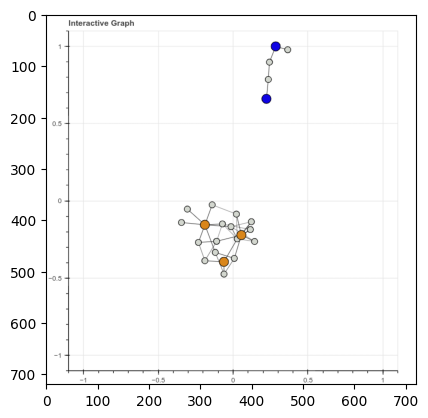

In [24]:
plt.imshow(img_all)

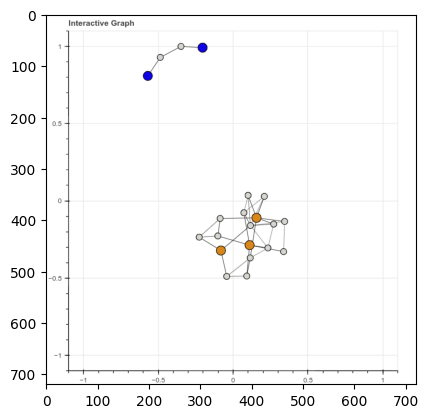

In [25]:
plt.imshow(img_sim)

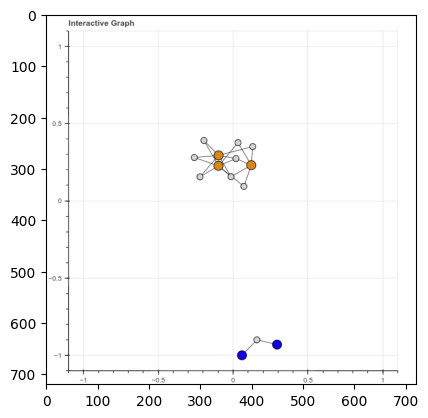

In [26]:
plt.imshow(img_hybrid)